<a href="https://colab.research.google.com/github/Sarvinoz0112/Week12_Lab/blob/main/Gradient_Descent_and_Polynomial_Regression_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent and Polynomial Regression

## Overview
In this lab, you will learn how to implement and compare three core optimization strategies used in machine learning:

- **Batch Gradient Descent (BGD)**
- **Stochastic Gradient Descent (SGD)**
- **Mini-Batch Gradient Descent (MBGD)**

You will first study the underlying mathematics and implement these methods **from scratch with NumPy**.
Then you will apply them to **polynomial regression**, analyze their behavior, and complete hands-on exercises.

## Learning Objectives
By the end of this lab, you should be able to:

1. Explain how gradient descent minimizes a cost function.
2. Derive and implement update rules for BGD, SGD, and MBGD.
3. Build polynomial features for nonlinear curve fitting.
4. Compare optimization methods in terms of speed, stability, and final performance.
5. Critically evaluate hyperparameters such as learning rate and batch size.

In [1]:
# =============================
# Imports and visual settings
# =============================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1) Gradient Descent: Concept and Mathematics

### Why Gradient Descent?
For many machine learning models, we define a loss (or cost) function and want to find model parameters that minimize it.
Gradient descent is an iterative optimization algorithm that updates parameters in the direction of the **negative gradient** of the loss.

### Linear Model Form
We use a hypothesis:

$$
\hat{y} = X\theta
$$

where:
- $X \in \mathbb{R}^{m \times n}$ is the design matrix,
- $\theta \in \mathbb{R}^{n \times 1}$ are model parameters,
- $\hat{y} \in \mathbb{R}^{m \times 1}$ are predictions.

### Cost Function (Mean Squared Error)

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

In matrix form:

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

### Gradient of MSE

$$
\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)
$$

### Update Rule

$$
\theta := \theta - \eta \nabla_\theta J(\theta)
$$

where $\eta$ is the learning rate.

---

## Three Variants

1. **Batch GD**: Uses all training examples each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{m}X^T(X\theta - y)
   $$

2. **Stochastic GD (SGD)**: Uses one sample at a time.
   $$
   \theta := \theta - \eta \cdot x_i^T(x_i\theta - y_i)
   $$

3. **Mini-Batch GD**: Uses a small batch $B$ each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{|B|}X_B^T(X_B\theta - y_B)
   $$

Trade-off intuition:
- Batch: stable but can be slow per update.
- SGD: fast, noisy updates.
- Mini-Batch: balanced and widely used in practice.

In [3]:
class GradientDescentRegressor:
    """
    Linear regressor optimized using batch, stochastic, or mini-batch GD.
    """
    def __init__(self, method="batch", lr=0.01, epochs=200, batch_size=32, random_state=42):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        self.training_time = None

    def _compute_gradient(self, X, y):
        """Gradient of MSE cost with respect to theta."""
        m = X.shape[0]
        errors = X @ self.theta - y
        grad = (X.T @ errors) / m
        return grad

    def fit(self, X, y):
        """Train model parameters using selected GD method."""
        rng = np.random.default_rng(self.random_state)
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.loss_history = []

        start = time.perf_counter()

        for epoch in range(self.epochs):
            if self.method == "batch":
                grad = self._compute_gradient(X, y)
                self.theta -= self.lr * grad

            elif self.method == "sgd":
                # Shuffle indices each epoch for better stochastic behavior.
                indices = rng.permutation(m)
                for i in indices:
                    Xi = X[i:i+1]
                    yi = y[i:i+1]
                    grad = Xi.T @ (Xi @ self.theta - yi)  # batch size is 1
                    self.theta -= self.lr * grad

            elif self.method == "mini-batch":
                indices = rng.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_idx = indices[start_idx:start_idx + self.batch_size]
                    Xb = X[batch_idx]
                    yb = y[batch_idx]
                    grad = (Xb.T @ (Xb @ self.theta - yb)) / Xb.shape[0]
                    self.theta -= self.lr * grad

            else:
                raise ValueError("method must be 'batch', 'sgd', or 'mini-batch'")

            # Track full-dataset loss after each epoch.
            y_pred_epoch = X @ self.theta
            epoch_loss = mean_squared_error(y, y_pred_epoch)
            self.loss_history.append(epoch_loss)

        end = time.perf_counter()
        self.training_time = end - start
        return self

    def predict(self, X):
        """Predict targets for input matrix X."""
        return X @ self.theta

## 2) Simple Example: Compare BGD, SGD, and MBGD

We start with a simple linear dataset to compare convergence behavior of the three methods.

Model: $y = 4 + 3x + \epsilon$

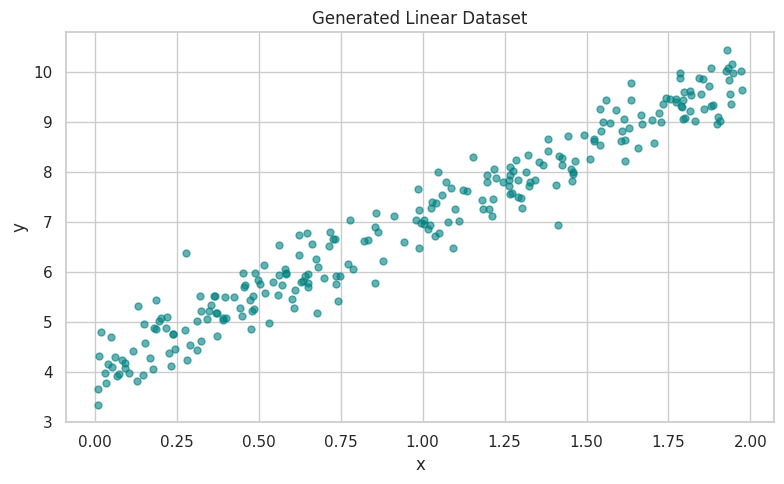

,Method,Final MSE,Training Time (s),Final Theta
0,Batch GD,0.218234,0.090148,"[3.606754282347466, 3.3500936172456846]"
1,SGD,0.156999,0.333890,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.077620,"[4.054809763947758, 2.9712473416164924]"


In [4]:
# Generate synthetic linear data
m = 250
X_raw = 2 * np.random.rand(m, 1)
noise = np.random.randn(m, 1) * 0.4
y = 4 + 3 * X_raw + noise

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, alpha=0.6, s=25, color="teal")
plt.title("Generated Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Add bias term for linear model
X = np.c_[np.ones((X_raw.shape[0], 1)), X_raw]

# Train all three variants
models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.08, epochs=50),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.01, epochs=50),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.03, epochs=50, batch_size=16)
}

results_simple = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    results_simple.append({
        "Method": name,
        "Final MSE": mean_squared_error(y, y_pred),
        "Training Time (s)": model.training_time,
        "Final Theta": model.theta.ravel()
    })

simple_results_df = pd.DataFrame(results_simple)
simple_results_df

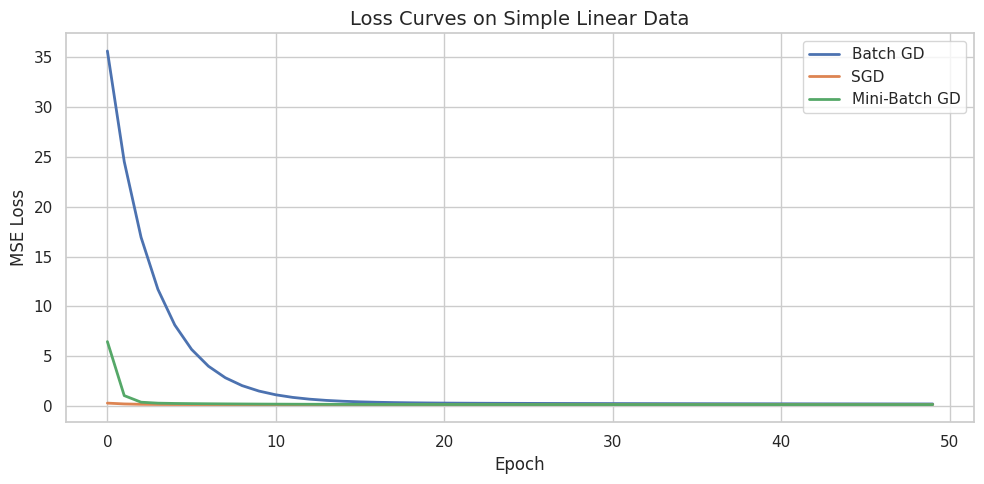

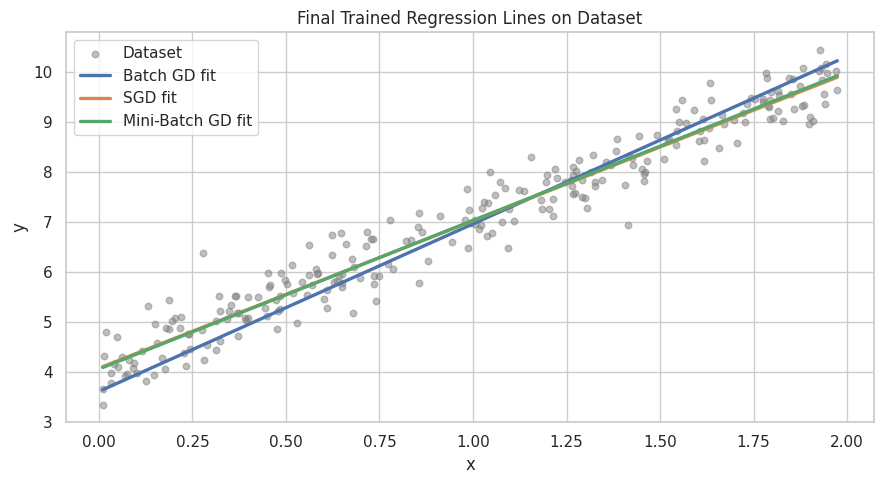

,Method,Final MSE,Training Time (s),Final Theta
1,SGD,0.156999,0.333890,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.077620,"[4.054809763947758, 2.9712473416164924]"
0,Batch GD,0.218234,0.090148,"[3.606754282347466, 3.3500936172456846]"


In [5]:
# Plot loss curves to compare convergence
plt.figure(figsize=(10, 5))
for name, model in models.items():
    plt.plot(model.loss_history, label=name, linewidth=2)

plt.title("Loss Curves on Simple Linear Data", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final trained regression lines on top of the dataset
x_line = np.linspace(X_raw.min(), X_raw.max(), 300).reshape(-1, 1)
X_line = np.c_[np.ones((x_line.shape[0], 1)), x_line]

plt.figure(figsize=(9, 5))
plt.scatter(X_raw, y, alpha=0.5, s=22, color="gray", label="Dataset")
for name, model in models.items():
    y_line_pred = model.predict(X_line)
    plt.plot(x_line, y_line_pred, linewidth=2.4, label=f"{name} fit")

plt.title("Final Trained Regression Lines on Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

display(simple_results_df.sort_values("Final MSE"))

### Interpretation
- **Batch GD** usually gives smoother convergence because each update uses the full dataset.
- **SGD** often converges quickly at first but exhibits noisier loss curves.
- **Mini-Batch GD** balances stability and computational efficiency.

In practice, mini-batch methods are widely used because they are GPU-friendly and often converge well.

## 3) Polynomial Regression from Scratch

### Why Polynomial Features?
A linear model in the original feature space can only fit straight lines/planes.
If the relationship between $x$ and $y$ is nonlinear, we can map input $x$ to polynomial features:

$$
\phi(x) = [x, x^2, x^3, \dots, x^d]
$$

Then fit a linear model in transformed space:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d
$$

This is still linear in parameters $\theta$, so gradient descent applies directly.

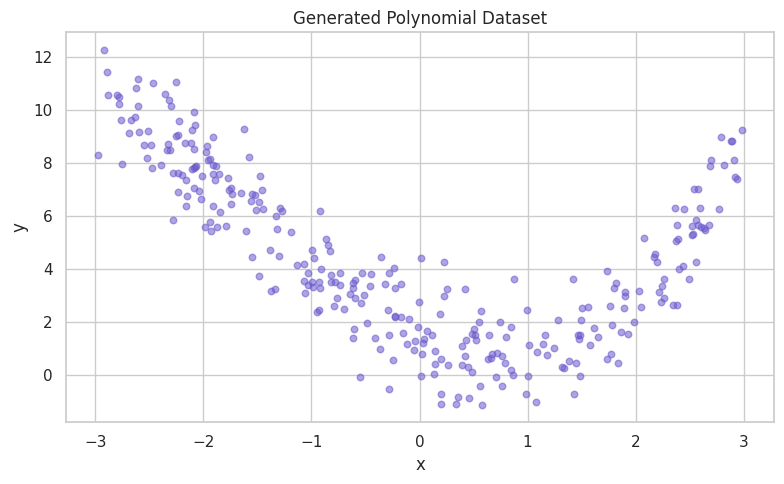

Polynomial data prepared.
Design matrix shape: (300, 4)


In [6]:
# Generate synthetic polynomial data
m_poly = 300
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + np.random.randn(m_poly, 1) * 1.2

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_poly, y_poly, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Create polynomial features up to degree 3 using sklearn
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_raw = poly.fit_transform(x_poly)

# Standardize polynomial features for stable GD updates using sklearn
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Add explicit bias for our from-scratch GD implementation
X_poly_design = np.c_[np.ones((X_poly_scaled.shape[0], 1)), X_poly_scaled]

print("Polynomial data prepared.")
print("Design matrix shape:", X_poly_design.shape)

In [7]:
# Train polynomial regression with all three GD variants
poly_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=250),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=250, batch_size=32)
}

poly_results = []
for name, model in poly_models.items():
    model.fit(X_poly_design, y_poly)
    y_pred = model.predict(X_poly_design)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    poly_results.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_poly, y_pred),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

,Method,Final MSE,Epochs to Converge,Training Time (s)
0,Batch GD,1.424179,195,0.149909
1,SGD,1.292687,12,0.620663
2,Mini-Batch GD,1.292398,86,0.151540


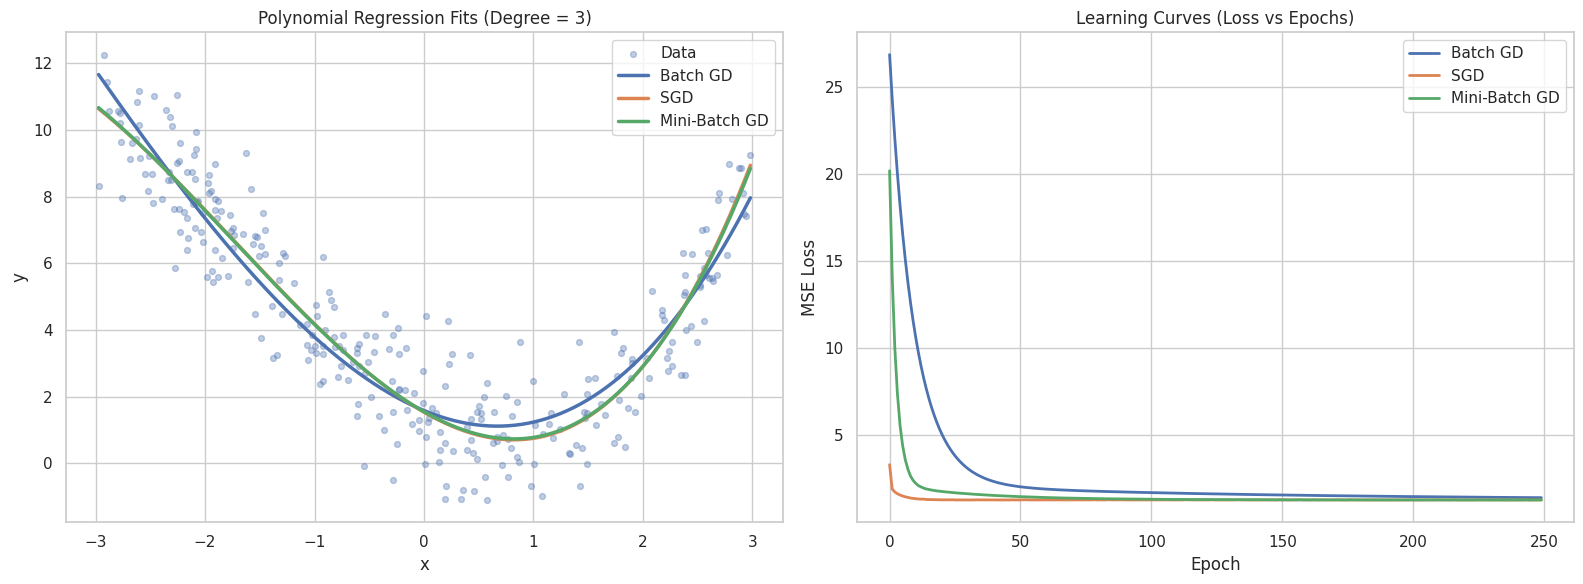

,Method,Final MSE,Epochs to Converge,Training Time (s)
2,Mini-Batch GD,1.292398,86,0.151540
1,SGD,1.292687,12,0.620663
0,Batch GD,1.424179,195,0.149909


In [8]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data")
for name, model in poly_models.items():
    y_grid_pred = model.predict(X_grid_design)
    axes[0].plot(x_grid, y_grid_pred, linewidth=2.5, label=name)

axes[0].set_title("Polynomial Regression Fits (Degree = 3)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curves
for name, model in poly_models.items():
    axes[1].plot(model.loss_history, linewidth=2, label=name)

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

display(poly_results_df.sort_values("Final MSE"))

### Observations
- All three methods can fit polynomial regression when features are engineered properly.
- Feature scaling is critical for numerical stability, especially for high-degree polynomial terms.
- SGD may oscillate more due to noisy updates, while Batch GD is smoother.
- Mini-Batch GD often gives a strong practical compromise.

# 4) Lab Exercises (Total: 100 points)

Complete the following tasks. Write clean code, include plots, and explain your findings in markdown.

## Task 1 (25 points)
**Implement Batch Gradient Descent from scratch** for a 4nd-degree polynomial regression on a new synthetic dataset (use different coefficients and noise from tutorial).

### Requirements
- Generate your own dataset.
- Build polynomial features (degree 4).
- Train using Batch GD.
- Plot fitted curve and learning curve.

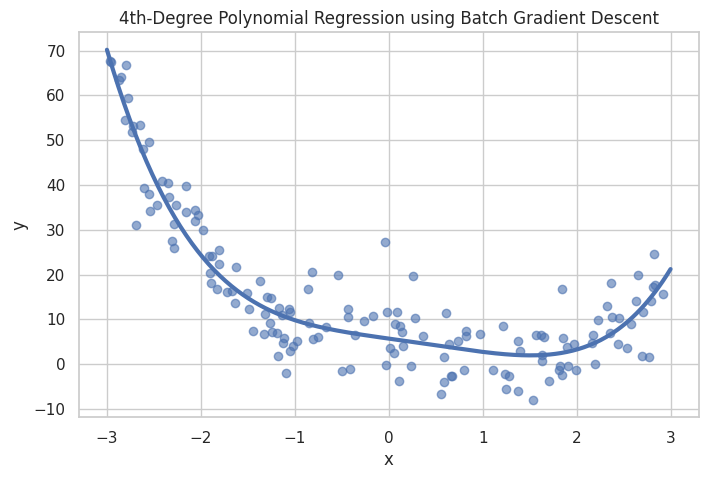

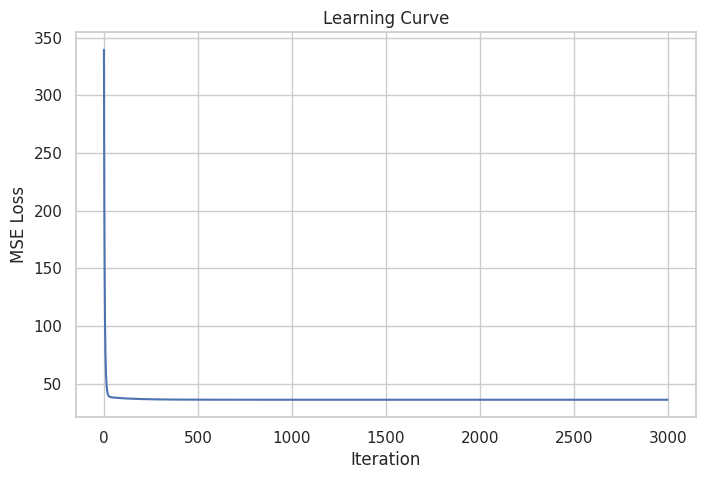

Final theta:
[[15.20762795]
 [-5.25659339]
 [ 0.24299649]
 [-6.02126364]
 [10.36302596]]
Final loss: 35.91205020469629


In [10]:
# -----------------------------
# Task 1 starter template
# -----------------------------
np.random.seed(42)

m = 150
x_t1 = np.random.uniform(-3, 3, m).reshape(-1, 1)
noise = np.random.normal(0, 6, m).reshape(-1, 1)

y_t1 = 4 - 2.5*x_t1 + 1.8*x_t1**2 - 0.7*x_t1**3 + 0.25*x_t1**4 + noise

X_poly = np.c_[x_t1, x_t1**2, x_t1**3, x_t1**4]

scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

X_b = np.c_[np.ones((m, 1)), X_poly_scaled]

eta = 0.05
n_iterations = 3000

theta = np.random.randn(5, 1)
loss_history = []

for iteration in range(n_iterations):
    gradients = (2 / m) * X_b.T.dot(X_b.dot(theta) - y_t1)
    theta = theta - eta * gradients
    loss = np.mean((X_b.dot(theta) - y_t1) ** 2)
    loss_history.append(loss)

x_new = np.linspace(-3, 3, 300).reshape(-1, 1)
X_new_poly = np.c_[x_new, x_new**2, x_new**3, x_new**4]
X_new_poly_scaled = scaler.transform(X_new_poly)
X_new_b = np.c_[np.ones((len(x_new), 1)), X_new_poly_scaled]

y_predict = X_new_b.dot(theta)

plt.figure(figsize=(8, 5))
plt.scatter(x_t1, y_t1, alpha=0.6)
plt.plot(x_new, y_predict, linewidth=3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("4th-Degree Polynomial Regression using Batch Gradient Descent")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

print("Final theta:")
print(theta)

print("Final loss:", loss_history[-1])

## Task 2 (25 points)
**Implement Stochastic Gradient Descent (SGD)** and tune the learning rate.

### Requirements
- Use one polynomial dataset.
- Try multiple learning rates (e.g., 0.0005, 0.001, 0.005, 0.01).
- Plot loss curves for each learning rate.
- Explain underfitting/divergence/instability if observed.

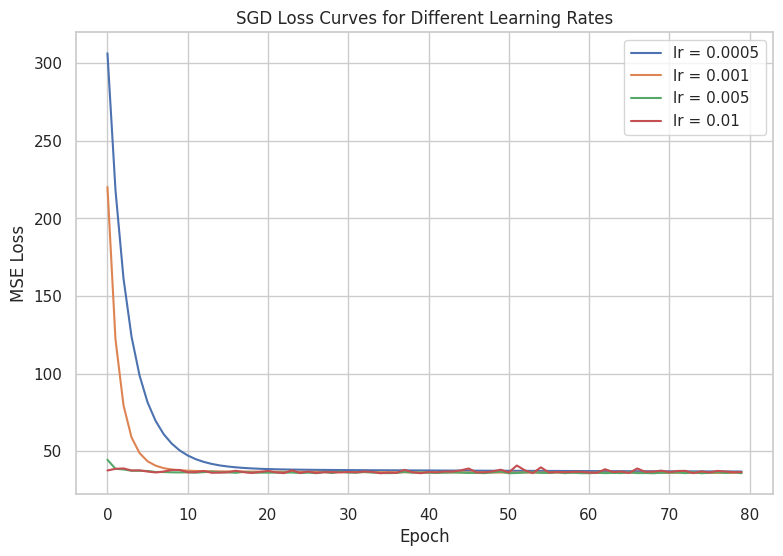

In [12]:
# -----------------------------
# Task 2 starter template
# -----------------------------
np.random.seed(42)

m = 150
x = np.random.uniform(-3, 3, m).reshape(-1, 1)
noise = np.random.normal(0, 6, m).reshape(-1, 1)

y = 4 - 2.5*x + 1.8*x**2 - 0.7*x**3 + 0.25*x**4 + noise

X_poly = np.c_[x, x**2, x**3, x**4]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_b = np.c_[np.ones((m, 1)), X_scaled]

learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}

n_epochs = 80

for lr in learning_rates:
    theta = np.random.randn(5, 1)
    history = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            gradient = 2 * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - lr * gradient

        loss = np.mean((X_b.dot(theta) - y) ** 2)
        history.append(loss)

    sgd_histories[lr] = history

plt.figure(figsize=(9, 6))

for lr, history in sgd_histories.items():
    plt.plot(history, label=f"lr = {lr}")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("SGD Loss Curves for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

# Learning rate = 0.0005: Loss decreases slowly. Training is stable but convergence is slow, so the model may underfit if epochs are too few.

# Learning rate = 0.001: Loss decreases faster than 0.0005 and remains stable. This is a good learning rate.

# Learning rate = 0.005: Loss usually decreases quickly, but the curve may be noisier because SGD updates weights after every sample.

# Learning rate = 0.01: Loss can become unstable. If the curve jumps up and down strongly or increases, the learning rate is too large and may cause divergence.

## Task 3 (25 points)
**Implement Mini-Batch Gradient Descent** and study different batch sizes.

### Requirements
- Try batch sizes: 8, 16, 32, 64.
- Keep other settings fixed (same learning rate, epochs, dataset).
- Plot loss curves for each batch size.
- Analyze trade-off: convergence speed vs stability.

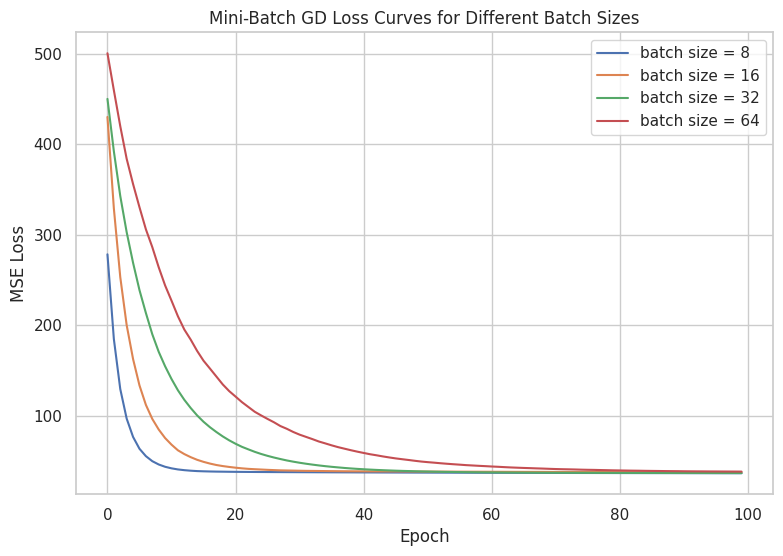

,Batch Size,Final MSE,Time
0,8,36.563327,0.112588
1,16,37.540887,0.034173
2,32,36.831670,0.032996
3,64,38.381132,0.024228


In [13]:
# -----------------------------
# Task 3 starter template
# -----------------------------
np.random.seed(42)

m = 150
X_t3 = np.random.uniform(-3, 3, m).reshape(-1, 1)
noise = np.random.normal(0, 6, m).reshape(-1, 1)

y_t3 = 4 - 2.5*X_t3 + 1.8*X_t3**2 - 0.7*X_t3**3 + 0.25*X_t3**4 + noise

X_poly = np.c_[X_t3, X_t3**2, X_t3**3, X_t3**4]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_b = np.c_[np.ones((m, 1)), X_scaled]

batch_sizes = [8, 16, 32, 64]
mbgd_histories = {}
mbgd_metrics = []

learning_rate = 0.005
n_epochs = 100

for bs in batch_sizes:
    theta = np.random.randn(5, 1)
    loss_history = []

    start_time = time.time()

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_shuffled = X_b[shuffled_indices]
        y_shuffled = y_t3[shuffled_indices]

        for i in range(0, m, bs):
            xi = X_shuffled[i:i+bs]
            yi = y_shuffled[i:i+bs]

            gradients = (2 / len(xi)) * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients

        loss = np.mean((X_b.dot(theta) - y_t3) ** 2)
        loss_history.append(loss)

    training_time = time.time() - start_time
    y_pred = X_b.dot(theta)

    mbgd_histories[bs] = loss_history
    mbgd_metrics.append({
        "Batch Size": bs,
        "Final MSE": mean_squared_error(y_t3, y_pred),
        "Time": training_time
    })

plt.figure(figsize=(9, 6))

for bs, history in mbgd_histories.items():
    plt.plot(history, label=f"batch size = {bs}")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Mini-Batch GD Loss Curves for Different Batch Sizes")
plt.legend()
plt.grid(True)
plt.show()

pd.DataFrame(mbgd_metrics)

# Batch size 8: Updates are frequent, so convergence can be fast, but the loss curve is usually more noisy.

# Batch size 16: Good balance between speed and stability. It is less noisy than batch size 8.

# Batch size 32: More stable updates, but convergence can be slightly slower because parameters update fewer times per epoch.

# Batch size 64: Most stable curve among these options, but it may converge more slowly because there are fewer updates per epoch.

## Task 4 (25 points)
**Compare Batch, SGD, and Mini-Batch GD** on the same polynomial regression dataset.

### Required comparison outputs
- Final MSE
- Number of epochs to converge
- Training time
- Final fitted curve quality (visual inspection)

Present a summary table and at least one comparison plot.

,Model,Final MSE,Epochs to Converge,Training Time
0,Batch GD,38.780712,300,0.009476
1,SGD,36.224485,67,0.120565
2,Mini-Batch GD,36.480712,300,0.043096


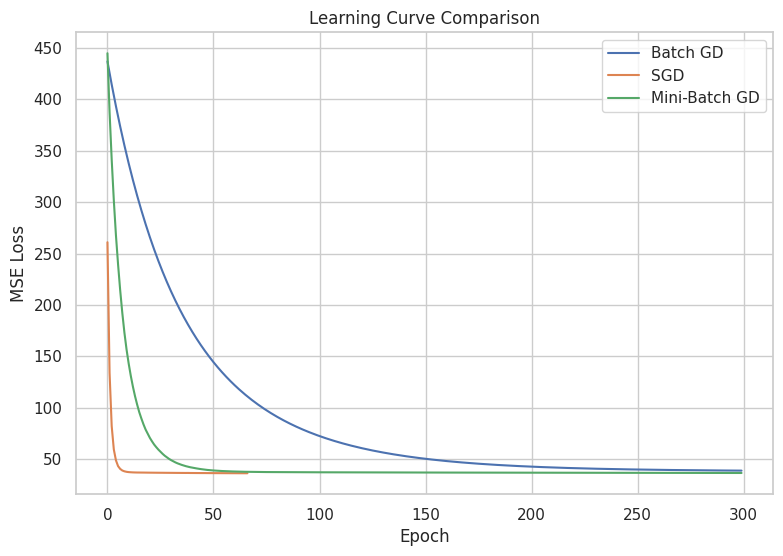

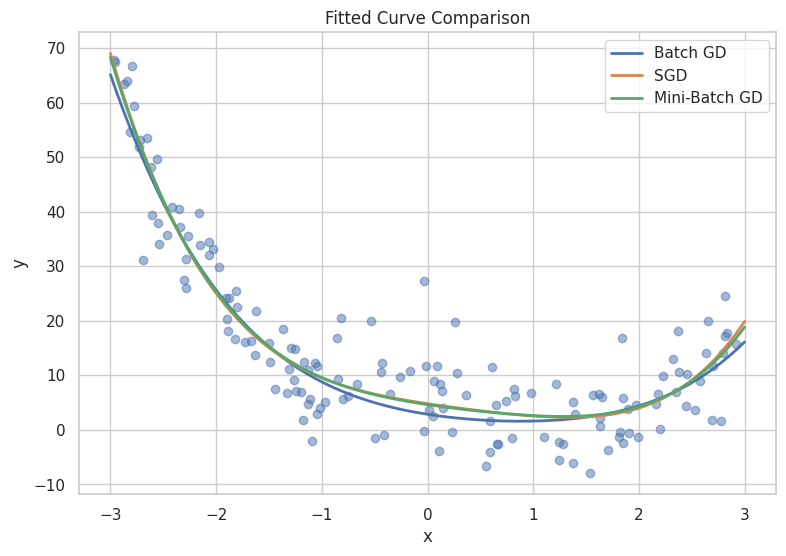

In [16]:
# -----------------------------
# Task 4 starter template
# -----------------------------
np.random.seed(42)

class GradientDescentRegressor:
    def __init__(self, method="batch", lr=0.005, epochs=100, batch_size=32, tol=1e-4):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.tol = tol
        self.theta = None
        self.loss_history = []
        self.training_time = 0
        self.epochs_to_converge = epochs

    def fit(self, X, y):
        m = len(X)
        self.theta = np.random.randn(X.shape[1], 1)
        start_time = time.time()

        for epoch in range(self.epochs):
            if self.method == "batch":
                gradients = (2 / m) * X.T.dot(X.dot(self.theta) - y)
                self.theta = self.theta - self.lr * gradients

            elif self.method == "sgd":
                indices = np.random.permutation(m)
                for i in indices:
                    xi = X[i:i+1]
                    yi = y[i:i+1]
                    gradients = 2 * xi.T.dot(xi.dot(self.theta) - yi)
                    self.theta = self.theta - self.lr * gradients

            elif self.method == "mini-batch":
                indices = np.random.permutation(m)
                X_shuffled = X[indices]
                y_shuffled = y[indices]

                for i in range(0, m, self.batch_size):
                    xi = X_shuffled[i:i+self.batch_size]
                    yi = y_shuffled[i:i+self.batch_size]
                    gradients = (2 / len(xi)) * xi.T.dot(xi.dot(self.theta) - yi)
                    self.theta = self.theta - self.lr * gradients

            loss = np.mean((X.dot(self.theta) - y) ** 2)
            self.loss_history.append(loss)

            if epoch > 5 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.tol:
                self.epochs_to_converge = epoch + 1
                break

        self.training_time = time.time() - start_time
        return self

    def predict(self, X):
        return X.dot(self.theta)


m = 150
X_t4 = np.random.uniform(-3, 3, m).reshape(-1, 1)
noise = np.random.normal(0, 6, m).reshape(-1, 1)

y_t4 = 4 - 2.5*X_t4 + 1.8*X_t4**2 - 0.7*X_t4**3 + 0.25*X_t4**4 + noise

X_poly = np.c_[X_t4, X_t4**2, X_t4**3, X_t4**4]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_b = np.c_[np.ones((m, 1)), X_scaled]

task4_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.005, epochs=300),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.001, epochs=300),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.005, epochs=300, batch_size=32)
}

task4_rows = []

for name, model in task4_models.items():
    model.fit(X_b, y_t4)
    y_pred = model.predict(X_b)

    task4_rows.append({
        "Model": name,
        "Final MSE": mean_squared_error(y_t4, y_pred),
        "Epochs to Converge": model.epochs_to_converge,
        "Training Time": model.training_time
    })

summary_df = pd.DataFrame(task4_rows)
display(summary_df)

plt.figure(figsize=(9, 6))

for name, model in task4_models.items():
    plt.plot(model.loss_history, label=name)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

x_new = np.linspace(-3, 3, 300).reshape(-1, 1)
X_new_poly = np.c_[x_new, x_new**2, x_new**3, x_new**4]
X_new_scaled = scaler.transform(X_new_poly)
X_new_b = np.c_[np.ones((len(x_new), 1)), X_new_scaled]

plt.figure(figsize=(9, 6))
plt.scatter(X_t4, y_t4, alpha=0.5)

for name, model in task4_models.items():
    y_new_pred = model.predict(X_new_b)
    plt.plot(x_new, y_new_pred, linewidth=2, label=name)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitted Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

# Batch GD is usually the most stable because it uses the full dataset for every update, but it can be slower per epoch.

# SGD updates after every sample, so it may converge quickly, but the loss curve is usually noisy and less stable.

# Mini-Batch GD gives a balance between Batch GD and SGD. It is faster than Batch GD and more stable than SGD.

# For fitted curve quality, all three methods should produce similar curves if the learning rate is tuned well and the model has enough epochs.

# 5) Bonus Questions (Theoretical - 10 points)

Answer the following conceptual questions in your own words.

### 1) (4 points)
**Explain the bias-variance tradeoff in the context of choosing the degree of the polynomial. What happens if the degree is too low or too high?**

**Your answer:**

The bias-variance tradeoff describes the balance between a model’s simplicity and its ability to fit the data.

If the polynomial degree is too low (e.g., degree 1 or 2):

The model is too simple
It cannot capture the true underlying relationship in the data
This leads to high bias
The model underfits (performs poorly on both training and test data)

If the polynomial degree is too high (e.g., degree 8 or higher):

The model becomes very flexible
It starts fitting not only the pattern but also the noise in the data
This leads to high variance
The model overfits (performs very well on training data but poorly on unseen data)

Optimal case:

The polynomial degree should be chosen so that the model captures the main pattern without fitting noise
This results in a good balance between bias and variance and better generalization

Summary:

Low degree → underfitting (high bias)
High degree → overfitting (high variance)
Moderate degree → best generalization

### 2) (3 points)
**Why does Stochastic Gradient Descent have higher variance in parameter updates compared to Batch Gradient Descent? How does Mini-Batch GD try to balance this?**

**Your answer:**

Stochastic Gradient Descent (SGD) updates model parameters using only one training example at a time. Because each example may be different, the computed gradient can vary significantly from step to step. This makes the updates noisy and results in high variance, causing the loss curve to fluctuate instead of decreasing smoothly.
In contrast, Batch Gradient Descent uses the entire dataset to compute the gradient, which gives a more accurate and stable estimate. This leads to low variance in updates but can be slower, especially for large datasets.
Mini-Batch Gradient Descent tries to balance these two approaches by using a small subset (batch) of the data for each update. This reduces the noise compared to SGD (lower variance) while still being faster and more efficient than full Batch GD.
In summary:


SGD → fast but noisy updates (high variance)


Batch GD → stable but slower updates (low variance)


Mini-Batch GD → a compromise that provides both reasonable speed and stability

### 3) (3 points)
**Discuss the importance of feature scaling when using Gradient Descent for polynomial regression. What problems can arise without scaling?**

**Your answer:**
Feature scaling is very important in polynomial regression when using Gradient Descent because polynomial features can have very different ranges. For example, if x is small, x^4 can still become very large, leading to large differences in feature magnitudes.
Without scaling:


Gradient Descent can become very slow because the cost function surface is stretched (elongated), causing inefficient updates


The algorithm may oscillate or zig-zag instead of moving directly toward the minimum


It can require a very small learning rate to remain stable


In some cases, it may even diverge (fail to converge)


With proper scaling (e.g., standardization):


All features are on a similar scale


Gradient Descent converges faster and more smoothly


Training becomes more stable and efficient


In summary, feature scaling helps ensure faster convergence, better stability, and more reliable optimization when training polynomial regression models with Gradient Descent.

# 6) Conclusion

In this lab, you:
- Implemented **Batch GD**, **SGD**, and **Mini-Batch GD** from scratch using NumPy.
- Compared optimization behavior through loss curves and empirical metrics.
- Applied gradient descent methods to **polynomial regression** with feature engineering.
- Explored practical tuning effects of learning rate and batch size.

Key takeaway: there is no single universally best optimizer setup. Effective training depends on balancing learning rate, batch size, feature scaling, and computational constraints.